link to the dataset: https://www.kaggle.com/datasets/okeemmanuel/movie-lens-dataset?select=movies.csv

In [14]:
# ============================================================================
# CELL 1: IMPORT ALL REQUIRED LIBRARIES
# ============================================================================
# Explanation: We import all the tools we need for data processing and recommendations

import pandas as pd                    # For handling data tables
import numpy as np                     # For mathematical operations
from sklearn.feature_extraction.text import TfidfVectorizer  # For text analysis
from sklearn.neighbors import NearestNeighbors  # For finding similar items
from sklearn.metrics.pairwise import cosine_similarity  # For measuring similarity
from scipy.sparse import csr_matrix, save_npz, load_npz  # For efficient storage
import matplotlib.pyplot as plt        # For creating graphs
import seaborn as sns                  # For better-looking graphs
import pickle                          # For saving models
import os                              # For file operations
import warnings
warnings.filterwarnings('ignore')      # Hide warning messages

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [15]:
# ============================================================================
# CELL 2: LOAD MOVIELENS DATASET FILES
# ============================================================================
# Explanation: We read the three CSV files that contain movie information

def load_data(movies_path, ratings_path, tags_path):
    """Load the three dataset files"""
    movies = pd.read_csv(movies_path)
    ratings = pd.read_csv(ratings_path)
    tags = pd.read_csv(tags_path)
    return movies, ratings, tags

# Load the files (update paths if needed)
movies, ratings, tags = load_data(
    "Dataset/movie.csv",
    "Dataset/rating.csv", 
    "Dataset/tag.csv"
)

print(f"Loaded {len(movies)} movies, {len(ratings)} ratings, {len(tags)} tags")
print("\nFirst 2 movies:")
print(movies.head(2))

Loaded 86537 movies, 33832162 ratings, 2328315 tags

First 2 movies:
   movieId             title                                       genres
0        1  Toy Story (1995)  Adventure|Animation|Children|Comedy|Fantasy
1        2    Jumanji (1995)                   Adventure|Children|Fantasy


In [16]:
# ============================================================================
# CELL 3: CLEAN AND PREPARE DATA
# ============================================================================
# Explanation: We clean the data by removing duplicates, combining tags, etc.

def clean_data(movies, ratings, tags):
    """Clean all data before using it"""
    
    # Step 1: Clean tags - remove empty ones and make lowercase
    tags = tags.dropna(subset=['tag'])
    tags['tag'] = tags['tag'].astype(str).str.lower()
    
    # Step 2: Combine multiple tags for same movie into one string
    tags_grouped = tags.groupby('movieId')['tag'].apply(lambda x: ' '.join(x)).reset_index()
    tags_grouped.columns = ['movieId', 'tags']
    
    # Step 3: Add tags to movies dataframe
    movies = movies.merge(tags_grouped, on='movieId', how='left')
    movies['tags'] = movies['tags'].fillna('')
    
    # Step 4: Clean genres - replace | with space and make lowercase
    movies['genres'] = movies['genres'].str.replace('|', ' ', regex=False)
    movies['genres'] = movies['genres'].str.lower()
    
    # Step 5: Create content feature (combine genres and tags)
    movies['content'] = movies['genres'] + ' ' + movies['tags']
    
    # Step 6: Remove duplicate movies
    movies = movies.drop_duplicates(subset=['movieId'])
    
    # Step 7: Use only 40% of ratings to save memory
    ratings = ratings.sample(frac=0.4, random_state=42)
    
    # Step 8: Combine ratings with movie info
    df = ratings.merge(movies, on='movieId')
    
    return df, movies

# Clean the data
df, movies_clean = clean_data(movies, ratings, tags)

print(f"Final dataset: {len(df)} ratings, {len(movies_clean)} movies")
print(f"Users: {df['userId'].nunique()}, Avg rating: {df['rating'].mean():.2f}")

Final dataset: 13532865 ratings, 86537 movies
Users: 320924, Avg rating: 3.54


In [17]:
# ============================================================================
# CELL 4: CONTENT-BASED RECOMMENDATION SYSTEM
# ============================================================================
# Explanation: This finds movies with similar genres and tags

def build_content_model(movies_df):
    """Build the content-based model using TF-IDF"""
    
    # Convert text to numbers (TF-IDF)
    tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
    tfidf_matrix = tfidf.fit_transform(movies_df['content'])
    
    # Create mapping: movie ID -> position in matrix
    movie_to_idx = {mid: i for i, mid in enumerate(movies_df['movieId'])}
    
    return tfidf, tfidf_matrix, movie_to_idx

def get_content_recs(movie_id, movies_df, tfidf_matrix, movie_to_idx, top_n=10):
    """Get similar movies using cosine similarity"""
    
    if movie_id not in movie_to_idx:
        return []
    
    # Get position of the movie
    idx = movie_to_idx[movie_id]
    
    # Calculate similarity with all movies
    similarities = cosine_similarity(tfidf_matrix[idx], tfidf_matrix).flatten()
    
    # Get top similar movies (skip the first one which is itself)
    top_indices = similarities.argsort()[::-1][1:top_n+1]
    
    recommendations = []
    for i in top_indices:
        if similarities[i] > 0.15:  # Only keep if similarity > 15%
            recommendations.append({
                'title': movies_df.iloc[i]['title'],
                'similarity': similarities[i],
                'genres': movies_df.iloc[i]['genres']
            })
    
    return recommendations

# Build the content model
tfidf, tfidf_matrix, movie_to_idx = build_content_model(movies_clean)
print("Content-based model ready!")
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")

Content-based model ready!
TF-IDF matrix shape: (86537, 5000)


In [18]:
# ============================================================================
# CELL 5: COLLABORATIVE FILTERING SYSTEM
# ============================================================================
# Explanation: This finds movies that users with similar taste also liked

def build_collab_model(ratings_df, movies_df):
    """Build collaborative filtering model using KNN"""
    
    # Map movie IDs to positions
    movie_to_idx = {mid: i for i, mid in enumerate(movies_df['movieId'])}
    
    # Convert user IDs to numbers
    users = ratings_df['userId'].astype('category').cat.codes.values
    movies = ratings_df['movieId'].map(movie_to_idx).values
    ratings = ratings_df['rating'].values
    
    # Create user-item matrix (rows=users, columns=movies)
    n_users = users.max() + 1
    n_movies = len(movie_to_idx)
    user_item_matrix = csr_matrix((ratings, (users, movies)), shape=(n_users, n_movies))
    
    # Train KNN model to find similar movies
    knn = NearestNeighbors(metric='cosine', algorithm='brute')
    knn.fit(user_item_matrix.T)  # Transpose for movie-based recommendations
    
    return user_item_matrix, knn, movie_to_idx

def get_collab_recs(movie_id, movies_df, user_item_matrix, knn, movie_to_idx, top_n=10):
    """Get recommendations based on what similar users liked"""
    
    if movie_id not in movie_to_idx:
        return []
    
    # Get position of the movie
    idx = movie_to_idx[movie_id]
    
    # Find similar movies
    distances, indices = knn.kneighbors(user_item_matrix.T[idx], n_neighbors=top_n+1)
    
    recommendations = []
    for i, dist in zip(indices[0][1:], distances[0][1:]):
        similarity = 1 - dist
        if similarity > 0.15:
            recommendations.append({
                'title': movies_df.iloc[i]['title'],
                'similarity': similarity,
                'genres': movies_df.iloc[i]['genres']
            })
    
    return recommendations

# Build the collaborative model
user_item_matrix, knn, collab_movie_to_idx = build_collab_model(df, movies_clean)
print("Collaborative model ready!")
print(f"User-Item matrix shape: {user_item_matrix.shape}")

Collaborative model ready!
User-Item matrix shape: (320924, 86537)


In [19]:
# ============================================================================
# CELL 6: HYBRID RECOMMENDATION SYSTEM
# ============================================================================
# Explanation: Combines content-based and collaborative filtering

def get_hybrid_recs(movie_id, movies_df, tfidf_matrix, movie_to_idx,
                    user_item_matrix, knn, collab_movie_to_idx,
                    top_n=10, content_weight=0.6):
    """
    Combine both methods using weighted average
    content_weight=0.6 means 60% content-based, 40% collaborative
    """
    
    # Get recommendations from both methods
    content_recs = get_content_recs(movie_id, movies_df, tfidf_matrix, movie_to_idx, top_n*2)
    collab_recs = get_collab_recs(movie_id, movies_df, user_item_matrix, knn, collab_movie_to_idx, top_n*2)
    
    # Combine scores
    scores = {}
    
    # Add content-based scores
    for rec in content_recs:
        scores[rec['title']] = {
            'score': rec['similarity'] * content_weight,
            'genres': rec['genres']
        }
    
    # Add collaborative scores
    for rec in collab_recs:
        if rec['title'] in scores:
            scores[rec['title']]['score'] += rec['similarity'] * (1 - content_weight)
        else:
            scores[rec['title']] = {
                'score': rec['similarity'] * (1 - content_weight),
                'genres': rec['genres']
            }
    
    # Sort by score and return top N
    sorted_recs = sorted(scores.items(), key=lambda x: x[1]['score'], reverse=True)
    
    results = []
    for title, data in sorted_recs[:top_n]:
        results.append({
            'title': title,
            'similarity': data['score'],
            'genres': data['genres']
        })
    
    return results

def recommend_movie(movie_name, top_n=5, content_weight=0.6):
    """Main function to get recommendations (user-friendly)"""
    
    # Find the movie
    matches = movies_clean[movies_clean['title'].str.contains(movie_name, case=False)]
    
    if len(matches) == 0:
        print(f"\nMovie '{movie_name}' not found!")
        return []
    
    # Get movie details
    target = matches.iloc[0]
    
    print(f"\n{'='*60}")
    print(f"Recommendations for: {target['title']}")
    print(f"Genres: {target['genres']}")
    print(f"{'='*60}\n")
    
    # Get hybrid recommendations
    recs = get_hybrid_recs(
        target['movieId'], movies_clean, tfidf_matrix, movie_to_idx,
        user_item_matrix, knn, collab_movie_to_idx,
        top_n, content_weight
    )
    
    # Display results
    for i, rec in enumerate(recs, 1):
        print(f"{i}. {rec['title']}")
        print(f"   Genres: {rec['genres']}")
        print(f"   Similarity: {rec['similarity']:.1%}\n")
    
    return recs

print("Hybrid system ready!")
print("\nTesting with 'Inception':")
recommend_movie("Inception", top_n=5)

Hybrid system ready!

Testing with 'Inception':

Recommendations for: Inception (2010)
Genres: action crime drama mystery sci-fi thriller imax

1. Shutter Island (2010)
   Genres: drama mystery thriller
   Similarity: 38.5%

2. Matrix, The (1999)
   Genres: action sci-fi thriller
   Similarity: 34.2%

3. Hello World (2019)
   Genres: animation romance sci-fi
   Similarity: 30.8%

4. Nines, The (2007)
   Genres: drama mystery
   Similarity: 28.2%

5. Europe, She Loves (2016)
   Genres: documentary
   Similarity: 28.2%



[{'title': 'Shutter Island (2010)',
  'similarity': 0.3846428437613087,
  'genres': 'drama mystery thriller'},
 {'title': 'Matrix, The (1999)',
  'similarity': 0.3418159698377827,
  'genres': 'action sci-fi thriller'},
 {'title': 'Hello World (2019)',
  'similarity': 0.3084215763036418,
  'genres': 'animation romance sci-fi'},
 {'title': 'Nines, The (2007)',
  'similarity': 0.28249556022048344,
  'genres': 'drama mystery'},
 {'title': 'Europe, She Loves (2016)',
  'similarity': 0.2821872785261494,
  'genres': 'documentary'}]

In [20]:
# ============================================================================
# CELL 7: EVALUATE RECOMMENDATION QUALITY
# ============================================================================
# Explanation: We measure how good our recommendations are using Precision and Recall

def precision_at_k(recommended, relevant, k=5):
    """Precision = how many of top K recommendations were actually relevant"""
    if len(recommended) == 0:
        return 0
    hits = len(set(recommended[:k]) & set(relevant))
    return hits / k

def recall_at_k(recommended, relevant, k=5):
    """Recall = how many relevant items we found in top K"""
    if len(relevant) == 0:
        return 0
    hits = len(set(recommended[:k]) & set(relevant))
    return hits / len(relevant)

def evaluate_system(num_users=20, k=5):
    """Test on random users to get average precision and recall"""
    
    # Get users with at least 10 ratings
    user_counts = df.groupby('userId').size()
    active_users = user_counts[user_counts >= 10].index.tolist()
    test_users = np.random.choice(active_users, min(num_users, len(active_users)), replace=False)
    
    precisions = []
    recalls = []
    
    for user_id in test_users:
        # Get user's liked movies (rating >= 4)
        user_ratings = df[df['userId'] == user_id]
        liked = user_ratings[user_ratings['rating'] >= 4]['movieId'].values
        
        if len(liked) < 2:
            continue
        
        # Use first liked movie as seed
        seed = liked[0]
        recs = get_hybrid_recs(seed, movies_clean, tfidf_matrix, movie_to_idx,
                              user_item_matrix, knn, collab_movie_to_idx, top_n=k)
        
        rec_titles = [r['title'] for r in recs]
        relevant_titles = set(movies_clean[movies_clean['movieId'].isin(liked[1:])]['title'].values)
        
        if relevant_titles:
            precisions.append(precision_at_k(rec_titles, relevant_titles, k))
            recalls.append(recall_at_k(rec_titles, relevant_titles, k))
    
    if precisions:
        print(f"\nEvaluation Results (tested on {len(precisions)} users):")
        print(f"Precision@{k}: {np.mean(precisions):.3f}")
        print(f"Recall@{k}: {np.mean(recalls):.3f}")
        print(f"F1-Score: {2 * np.mean(precisions) * np.mean(recalls) / (np.mean(precisions) + np.mean(recalls) + 1e-8):.3f}")

# Run evaluation
print("Evaluating system...")
evaluate_system(num_users=30, k=5)

Evaluating system...

Evaluation Results (tested on 30 users):
Precision@5: 0.020
Recall@5: 0.001
F1-Score: 0.003


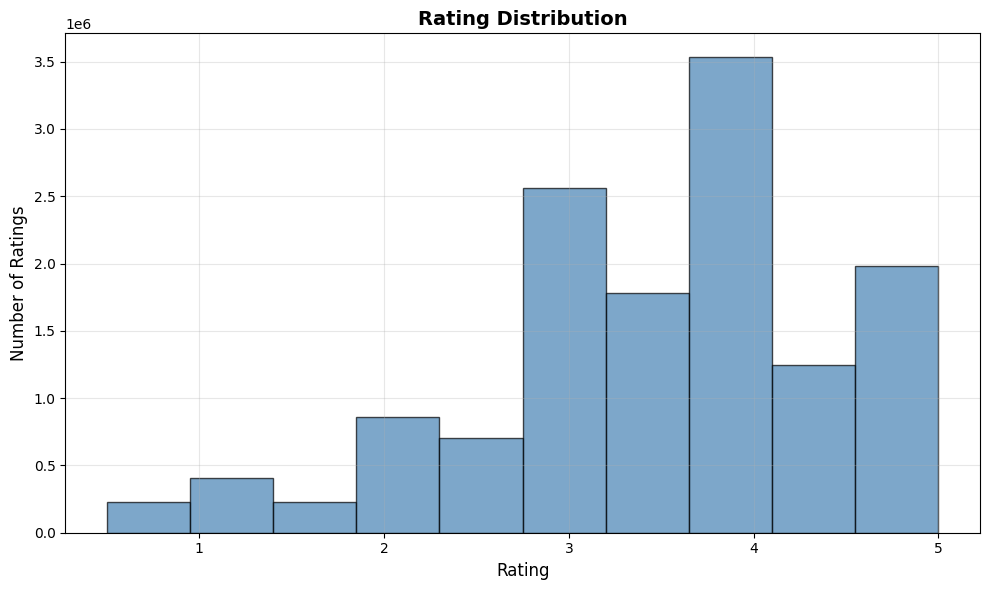

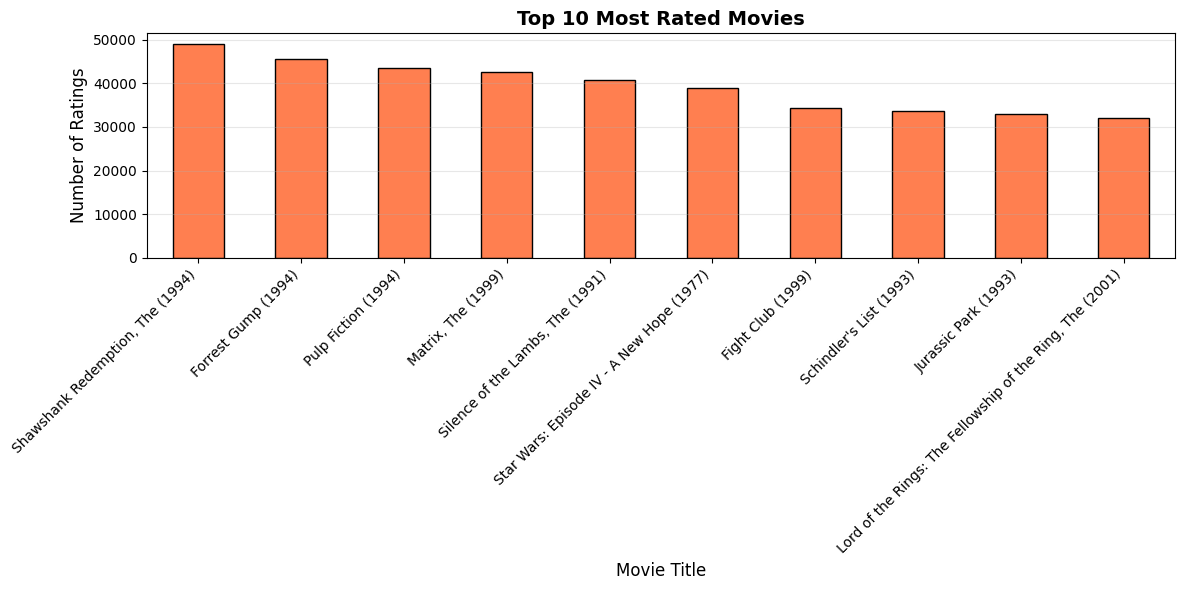

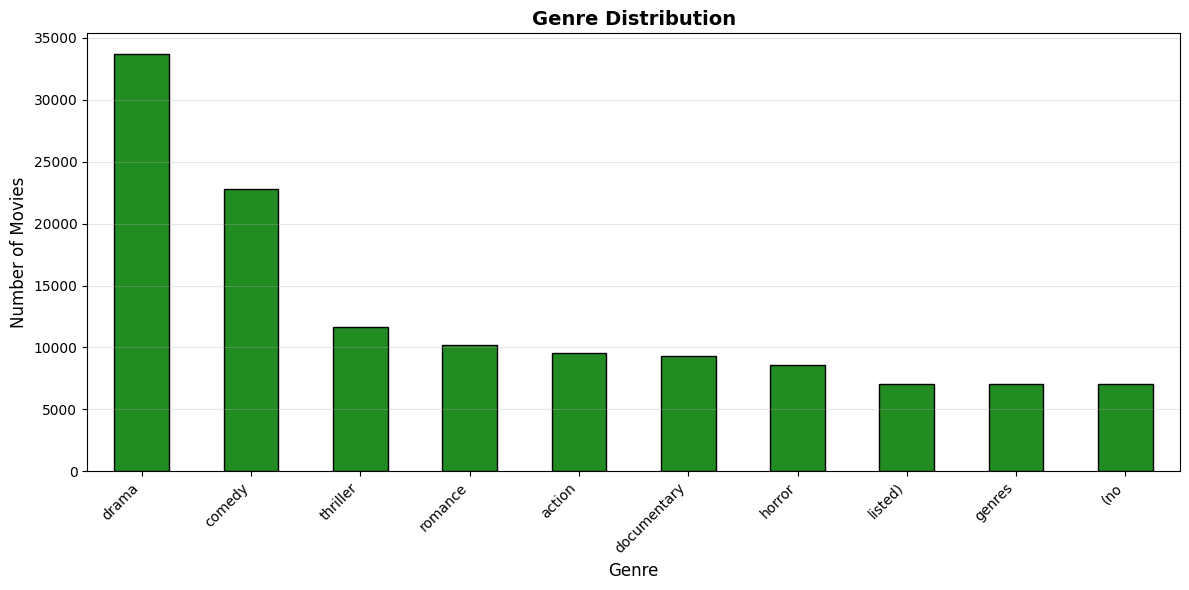


Visualizations complete!


In [25]:
# ============================================================================
# STEP 8: CREATE VISUALIZATIONS
# ============================================================================
# Explanation: We create 3 graphs as required by the client

import matplotlib.pyplot as plt
import seaborn as sns

# Graph 1: Rating Distribution
# ============================================================================
plt.figure(figsize=(10, 6))
plt.hist(df['rating'], bins=10, color='steelblue', edgecolor='black', alpha=0.7)
plt.title('Rating Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Number of Ratings', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Graph 2: Top 10 Most Rated Movies
# ============================================================================
plt.figure(figsize=(12, 6))
top_movies = df.groupby('title')['rating'].count().sort_values(ascending=False).head(10)
top_movies.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Top 10 Most Rated Movies', fontsize=14, fontweight='bold')
plt.xlabel('Movie Title', fontsize=12)
plt.ylabel('Number of Ratings', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Graph 3: Genre Distribution
# ============================================================================
all_genres = []
for genres in movies_clean['genres'].str.split():
    if genres:
        all_genres.extend(genres)

genre_counts = pd.Series(all_genres).value_counts().head(10)

plt.figure(figsize=(12, 6))
genre_counts.plot(kind='bar', color='forestgreen', edgecolor='black')
plt.title('Genre Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Number of Movies', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("\nVisualizations complete!")

In [26]:
# ============================================================================
# CELL 9: SAVE MODELS FOR LATER USE
# ============================================================================
# Explanation: We save all trained models so we can use them without retraining

def save_models():
    """Save all models to disk"""
    
    os.makedirs('models', exist_ok=True)
    
    # Save each component
    with open('models/tfidf.pkl', 'wb') as f:
        pickle.dump(tfidf, f)
    
    with open('models/movie_to_idx.pkl', 'wb') as f:
        pickle.dump(movie_to_idx, f)
    
    with open('models/knn.pkl', 'wb') as f:
        pickle.dump(knn, f)
    
    with open('models/movies.pkl', 'wb') as f:
        pickle.dump(movies_clean, f)
    
    # Save matrices (sparse format for efficiency)
    save_npz('models/tfidf_matrix.npz', tfidf_matrix)
    save_npz('models/user_item_matrix.npz', user_item_matrix)
    
    print("All models saved to 'models/' folder!")

# Save everything
print("Saving models...")
save_models()

Saving models...
All models saved to 'models/' folder!


In [27]:
# ============================================================================
# CELL 10: UTILITY FUNCTIONS (Search, Popular, etc.)
# ============================================================================
# Explanation: Helper functions for searching and finding popular movies

def search_movies(query, limit=10):
    """Search for movies by name"""
    query = query.lower()
    results = movies_clean[movies_clean['title'].str.lower().str.contains(query)]
    return results['title'].head(limit).tolist()

def get_popular_movies(min_ratings=5, top_n=10):
    """Get most popular movies (for new users)"""
    stats = df.groupby('movieId').agg({'rating': ['mean', 'count']}).reset_index()
    stats.columns = ['movieId', 'avg_rating', 'count']
    popular = stats[stats['count'] >= min_ratings].sort_values('avg_rating', ascending=False)
    
    results = []
    for _, row in popular.head(top_n).iterrows():
        title = movies_clean[movies_clean['movieId'] == row['movieId']]['title'].values[0]
        results.append((title, row['avg_rating'], row['count']))
    
    return results

def get_movies_by_genre(genre, top_n=10):
    """Get movies from a specific genre"""
    genre = genre.lower()
    matches = movies_clean[movies_clean['genres'].str.contains(genre)]
    return matches['title'].head(top_n).tolist()

# Test the utilities
print("Testing search: 'matrix'")
print(search_movies("matrix", limit=3))

print("\nPopular movies:")
popular = get_popular_movies(min_ratings=10, top_n=5)
for i, (title, rating, count) in enumerate(popular, 1):
    print(f"{i}. {title} (Rating: {rating:.2f}, {count} ratings)")

Testing search: 'matrix'
['Matrix, The (1999)', 'Matrix Reloaded, The (2003)', 'Matrix Revolutions, The (2003)']

Popular movies:
1. James Acaster: Cold Lasagne Hate Myself 1999 (2020) (Rating: 4.50, 10.0 ratings)
2. River, The (He liu) (1997) (Rating: 4.45, 11.0 ratings)
3. Planet Earth (2006) (Rating: 4.45, 1247.0 ratings)
4. Planet Earth II (2016) (Rating: 4.44, 836.0 ratings)
5. Shawshank Redemption, The (1994) (Rating: 4.42, 48992.0 ratings)


In [28]:
# ============================================================================
# CELL 11: COMMAND LINE INTERFACE
# ============================================================================
# Explanation: Interactive menu for users to get recommendations

def main_menu():
    """Interactive command line menu"""
    
    print("\n" + "="*60)
    print("MOVIE RECOMMENDATION SYSTEM")
    print("Content-Based + Collaborative Filtering")
    print("="*60)
    
    while True:
        print("\n" + "-"*40)
        print("MAIN MENU")
        print("-"*40)
        print("1. Get movie recommendations")
        print("2. Search for a movie")
        print("3. Browse by genre")
        print("4. View popular movies")
        print("5. Exit")
        
        choice = input("\nEnter your choice (1-5): ")
        
        if choice == '1':
            movie = input("Enter movie name: ").strip()
            if movie:
                recommend_movie(movie, top_n=5)
        
        elif choice == '2':
            query = input("Search for movie: ").strip()
            if query:
                results = search_movies(query, limit=10)
                if results:
                    print(f"\nFound {len(results)} movies:")
                    for i, title in enumerate(results, 1):
                        print(f"  {i}. {title}")
                    
                    pick = input("\nGet recommendations? (enter number or 'no'): ")
                    if pick.isdigit() and 1 <= int(pick) <= len(results):
                        recommend_movie(results[int(pick)-1])
                else:
                    print(f"No movies found for '{query}'")
        
        elif choice == '3':
            print("\nPopular genres: action, comedy, drama, romance, thriller, sci-fi")
            genre = input("Enter genre: ").strip().lower()
            if genre:
                movies = get_movies_by_genre(genre, top_n=10)
                if movies:
                    print(f"\nTop {genre.upper()} movies:")
                    for i, title in enumerate(movies, 1):
                        print(f"  {i}. {title}")
                    
                    pick = input("\nGet recommendations? (enter number or 'no'): ")
                    if pick.isdigit() and 1 <= int(pick) <= len(movies):
                        recommend_movie(movies[int(pick)-1])
                else:
                    print(f"No movies found in '{genre}' genre")
        
        elif choice == '4':
            print("\nMost Popular Movies:")
            popular = get_popular_movies(min_ratings=10, top_n=10)
            for i, (title, rating, count) in enumerate(popular, 1):
                print(f"{i}. {title} (Rating: {rating:.2f}, {count} ratings)")
        
        elif choice == '5':
            print("\nThank you for using the system! Goodbye!")
            break
        
        else:
            print("Invalid choice. Please enter 1-5.")

# Run the interface
if __name__ == "__main__":
    main_menu()


MOVIE RECOMMENDATION SYSTEM
Content-Based + Collaborative Filtering

----------------------------------------
MAIN MENU
----------------------------------------
1. Get movie recommendations
2. Search for a movie
3. Browse by genre
4. View popular movies
5. Exit



Thank you for using the system! Goodbye!
